# Backbone Comparison

In this notebook, we compare multiple backbones for **jaguar re-identification**. In the [Baseline Notebook](jaguar-reidentification-megadescriptor-arcfaceloss.ipynb), the **MegaDescriptor** model was used as the baseline. Here, we evaluate whether alternative backbones can achieve better performance.

For each backbone, we generate embeddings for the dataset. Based on these embeddings, we train an **embedding projection model** and compare the resulting **identity-balanced mAP** on the validation set. The training configuration is largely kept consistent with the setup used in the [Baseline Notebook](jaguar-reidentification-megadescriptor-arcfaceloss.ipynb). Since the embedding dimensionality varies across backbones, the input size of the embedding projection model is adjusted accordingly. We use blurred backgrounds, as this intervention improved performance in the [Background Interventions Notebook](01_background_interventions.ipynb).


In addition to performance, we also analyze the **efficiency** of the models by tracking embedding time, training time of the embedding projection model, and the number of model parameters.

The following backbones are evaluated:

1. **MegaDescriptor**
2. **CLIP**
3. **DINOv3**
4. **EfficientNet**
5. **ResNet18**


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters needed for the subsequent exploratory data analysis.

In [1]:
EXPERIMENT_NAME = "02_backbone_comparison"
RANDOM_SEED = 21 # 4, 7, 90, 856, 21

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import ArcFaceLoss
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 21 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

We keep the training configuration largely the same as the baseline approach. The number of epochs is increased, as the best identity-balanced mAP was observed to improve after 50 epochs.


In [3]:
# Configuration
config = {   
    # MegaDescriptor Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "megadescriptor_input_size": 384,
    
    # Clip Model
    "clip_model": "hf-hub:timm/vit_base_patch16_clip_224.openai",
    "clip_input_size": 224,
    
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,
    
    # EfficientNet Model
    "efficientnet_model": "hf-hub:timm/efficientnet_b0.ra_in1k",
    "efficientnet_input_size": 384,

    # ResNet18 Model
    "resnet18_model": "hf-hub:timm/resnet18.a1_in1k",
    "resnet18_input_size": 224,

    # ArcFace Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Scheduler
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  megadescriptor_input_size: 384
  clip_model: hf-hub:timm/vit_base_patch16_clip_224.openai
  clip_input_size: 224
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  efficientnet_model: hf-hub:timm/efficientnet_b0.ra_in1k
  efficientnet_input_size: 384
  resnet18_model: hf-hub:timm/resnet18.a1_in1k
  resnet18_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  scheduler_factor: 0.5
  scheduler_patience: 5
  seed: 21


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Create stratified train/validation split to ensure all identities appear in train and validation set.

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


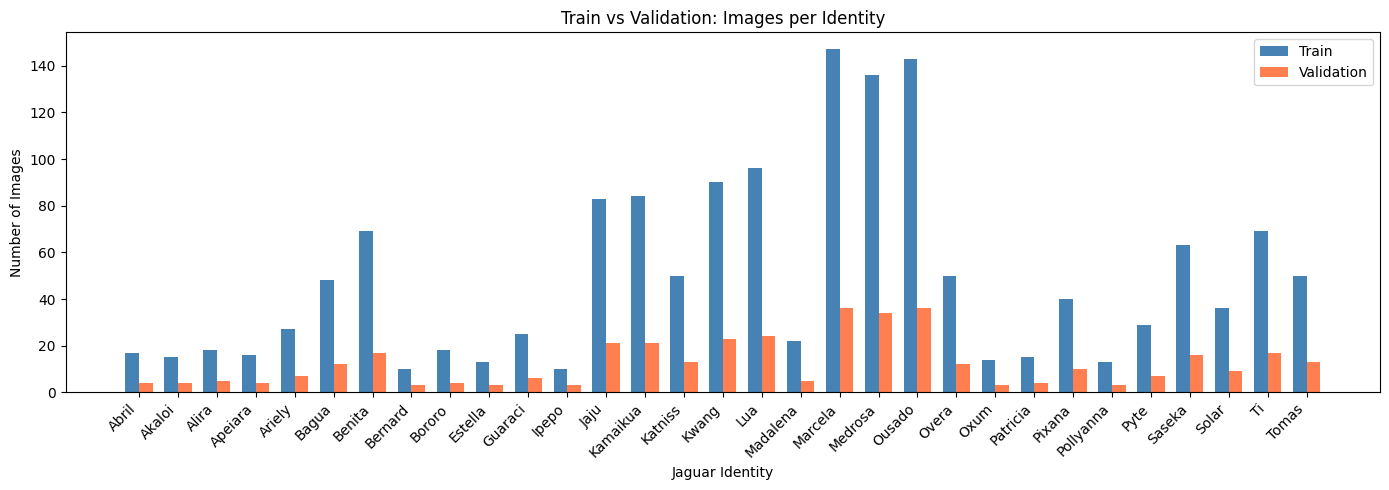


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda
Using num_workers=8 for DataLoader


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [9]:
criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

print(f"Loss Function: ArcFaceLoss")
print(f"  Margin: {config['arcface_margin']}")
print(f"  Scale: {config['arcface_scale']}")

Loss Function: ArcFaceLoss
  Margin: 0.5
  Scale: 64.0


Since **ArcFace Loss** includes learnable weights, it must be reset before retraining the embedding projection model.

In [10]:
initial_criterion_weights_path = CHECKPOINT_PATH / "criterion_initial_weights.pth"
torch.save(criterion.state_dict(), initial_criterion_weights_path)
print(f"Initial criterion weights saved to {initial_criterion_weights_path}")

Initial criterion weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/02_backbone_comparison/criterion_initial_weights.pth


In [11]:
table = [
    ["Backbone", "Best val_mAP", "Best epoch", "Backbone Params", "Projection Params", "Embedding Time", "Training Time"]
]

## Megadescriptor

**MegaDescriptor** was used in the baseline notebook and serves as the baseline backbone for this experiment. It was pretrained on wildlife re-identification datasets, which is beneficial for this use case.


In [12]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)
megadescriptor.compile()

# Get the default data configuration for the model and create the preprocessing transform
megadescriptor_config = resolve_data_config({}, model=megadescriptor)
megadescriptor_preprocess = create_transform(**megadescriptor_config, is_training=False)

megadescriptor_num_params = sum(p.numel() for p in megadescriptor.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {megadescriptor_num_params:,}")
print(f"  Preprocessing: {megadescriptor_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = megadescriptor_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

wandb.log({
    "megadescriptor_num_params": megadescriptor_num_params,
    "megadescriptor_embedding_dim": megadescriptor_dim,
    "megadescriptor_input_size": megadescriptor_config["input_size"],
    "megadescriptor_preprocessing": str(megadescriptor_config),
})

Loading MegaDescriptor-L-384 model...


Model loaded successfully
  Parameters: 195,198,516
  Preprocessing: {'input_size': [3, 384, 384], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 1536


In [13]:
megadescriptor_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=megadescriptor_preprocess
)
megadescriptor_loader = DataLoader(
    megadescriptor_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
)

print(f"MegaDescriptor DataLoader created with {len(megadescriptor_loader)} batches")

MegaDescriptor DataLoader created with 60 batches


Embeddings are extracted only once for each backbone. Therefore, embedding time is recorded a single time for comparison purposes in order to reduce computational cost.


In [14]:
megadescriptor_cache_path = OUTPUT_PATH / "megadescriptor_blur_embeddings.npz"

start_time = time.time()
megadescriptor_embeddings = get_embeddings(
    model=megadescriptor,
    cache_path=megadescriptor_cache_path,
    data_loader=megadescriptor_loader,
    filenames=filenames,
    device=device
)
megadescriptor_embedding_time = time.time() - start_time
print(f"Embeddings extracted in {megadescriptor_embedding_time:.2f} seconds")

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/02_backbone_comparison/megadescriptor_blur_embeddings.npz
Embeddings shape: (1895, 1536)
Embeddings extracted in 0.06 seconds


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


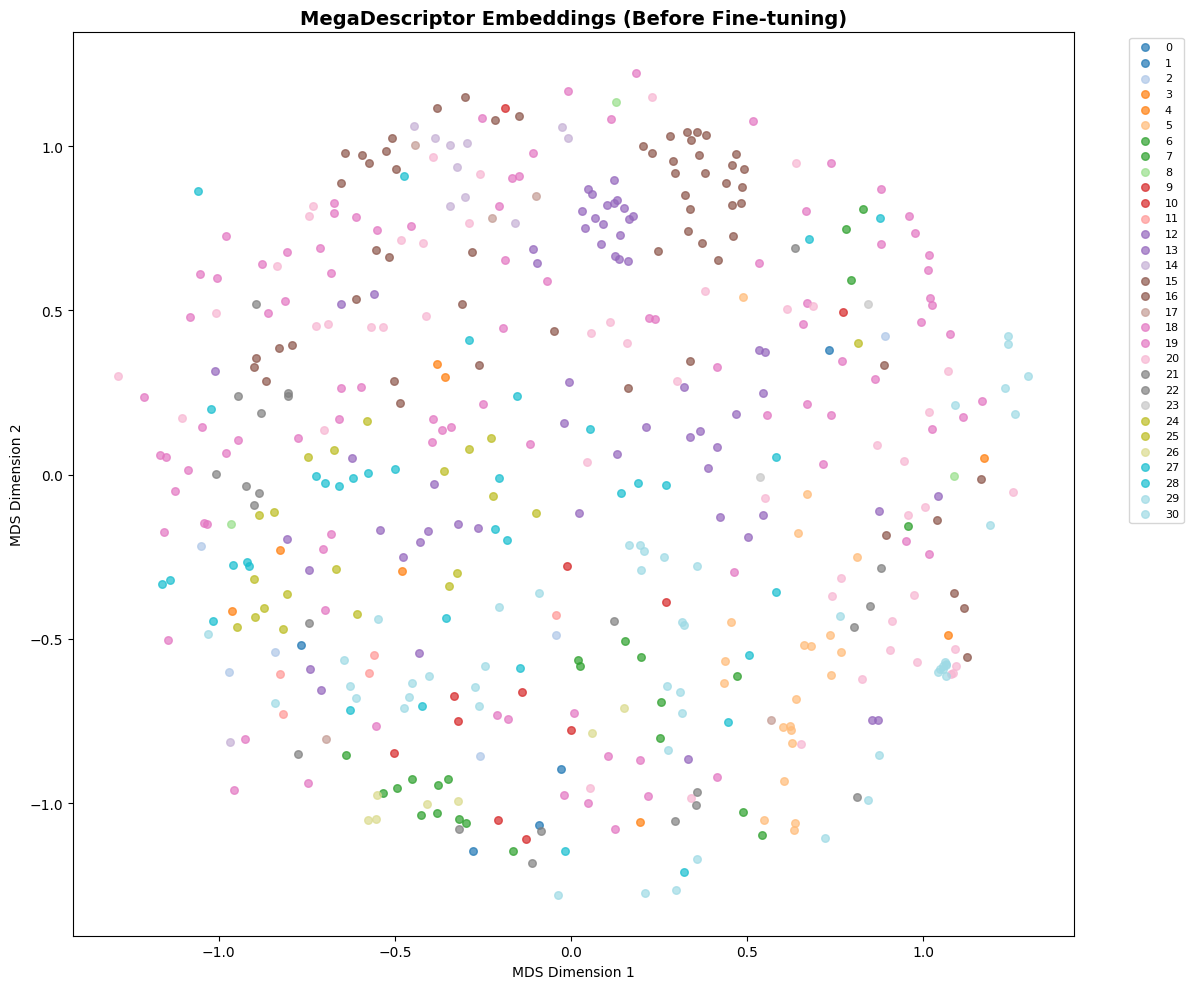

In [15]:
# Visualize MegaDescriptor embeddings
fig = visualize_embeddings_mds(
    megadescriptor_embeddings,
    labels,
    "MegaDescriptor Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "megadescriptor_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"megadescriptor_embeddings_mds": wandb.Image(fig)})

In [16]:
megadescriptor_emb_train_dataset = EmbeddingDataset(
    megadescriptor_embeddings[train_mask],
    train_labels
)

megadescriptor_emb_val_dataset = EmbeddingDataset(
    megadescriptor_embeddings[~train_mask],
    val_labels
)

megadescriptor_emb_train_loader = create_deterministic_training_dataloader(
    megadescriptor_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    seed=config["seed"]
)
megadescriptor_emb_val_loader = DataLoader(
    megadescriptor_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

For the embedding projection model, we determine the input dimensionality corresponding to each backbone’s embedding output.


In [17]:
# Create model
model = EmbeddingProjection(
    input_dim=megadescriptor_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 1536
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 919808


In [18]:
# Setup training components
criterion.load_state_dict(torch.load(initial_criterion_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"]
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [19]:
# Training loop
set_seeds(config['seed'])
megadescriptor_checkpoint_path = CHECKPOINT_PATH / "best_megadescriptor_arcface.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    megadescriptor_emb_train_loader, 
    megadescriptor_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="megadescriptor",
    checkpoint_path=megadescriptor_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_megadescriptor": best_map,
    "best_epoch_megadescriptor": best_epoch,
    "total_epochs_megadescriptor": len(history['train_loss']),
    "training_time_megadescriptor": training_time,
})

table.append([
    "MegaDescriptor",
    best_map,
    best_epoch,
    megadescriptor_num_params,
    sum(p.numel() for p in model.parameters()),
    megadescriptor_embedding_time,
    training_time
])

All random seeds set to 21 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 37.0517
  Val Loss:   33.0420
  Val mAP:    0.2681 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.4074
  Val Loss:   28.8013
  Val mAP:    0.2857 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.2053
  Val Loss:   25.7907
  Val mAP:    0.3052 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.4728
  Val Loss:   5.9799
  Val mAP:    0.7283 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 63/200


  Train Loss: 0.5577
  Val Loss:   5.8794
  Val mAP:    0.7321 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 64/200


  Train Loss: 0.4381
  Val Loss:   6.0067
  Val mAP:    0.7309 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 65/200


  Train Loss: 0.4411
  Val Loss:   5.9783
  Val mAP:    0.7238 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 66/200


  Train Loss: 0.3768
  Val Loss:   5.9749
  Val mAP:    0.7249 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 66 epochs

Training complete!
Best epoch: 56, Val mAP: 0.7333


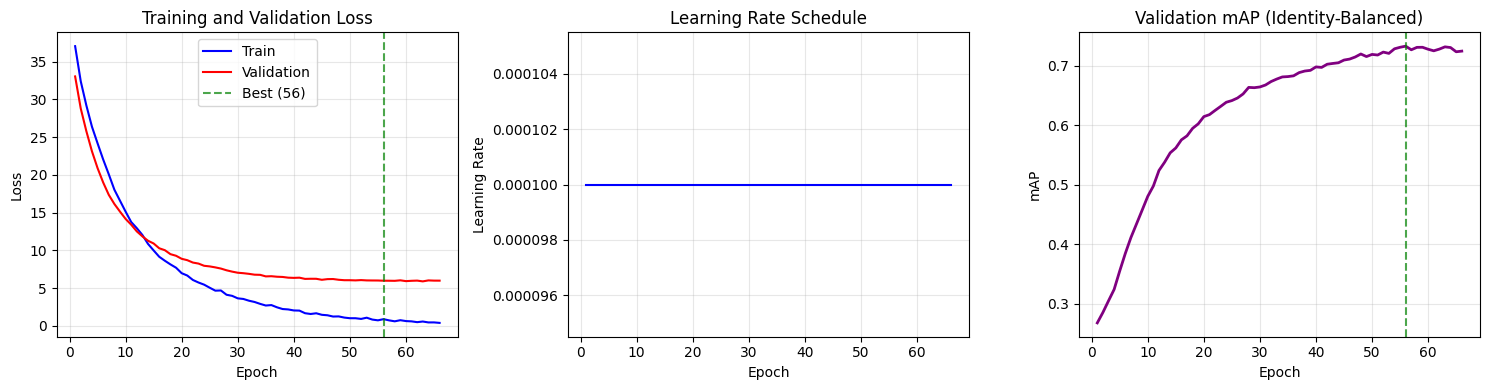

In [20]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_megadescriptor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_megadescriptor": wandb.Image(fig)})

In [21]:
# Load best model
checkpoint = torch.load(megadescriptor_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 56
  Val mAP: 0.7333


In [22]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(megadescriptor_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


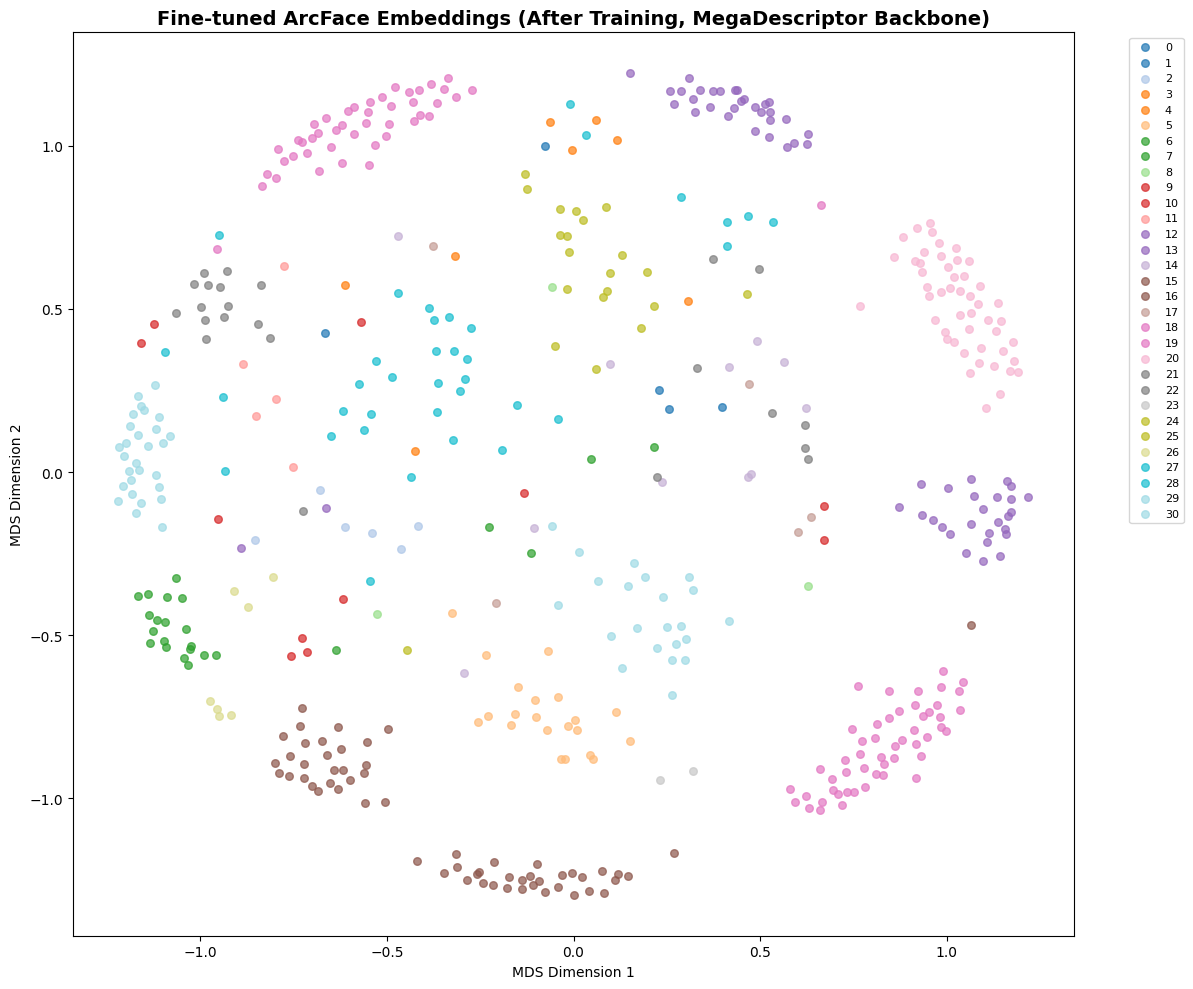

In [23]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, MegaDescriptor Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "megadescriptor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_megadescriptor": wandb.Image(fig_finetuned)})

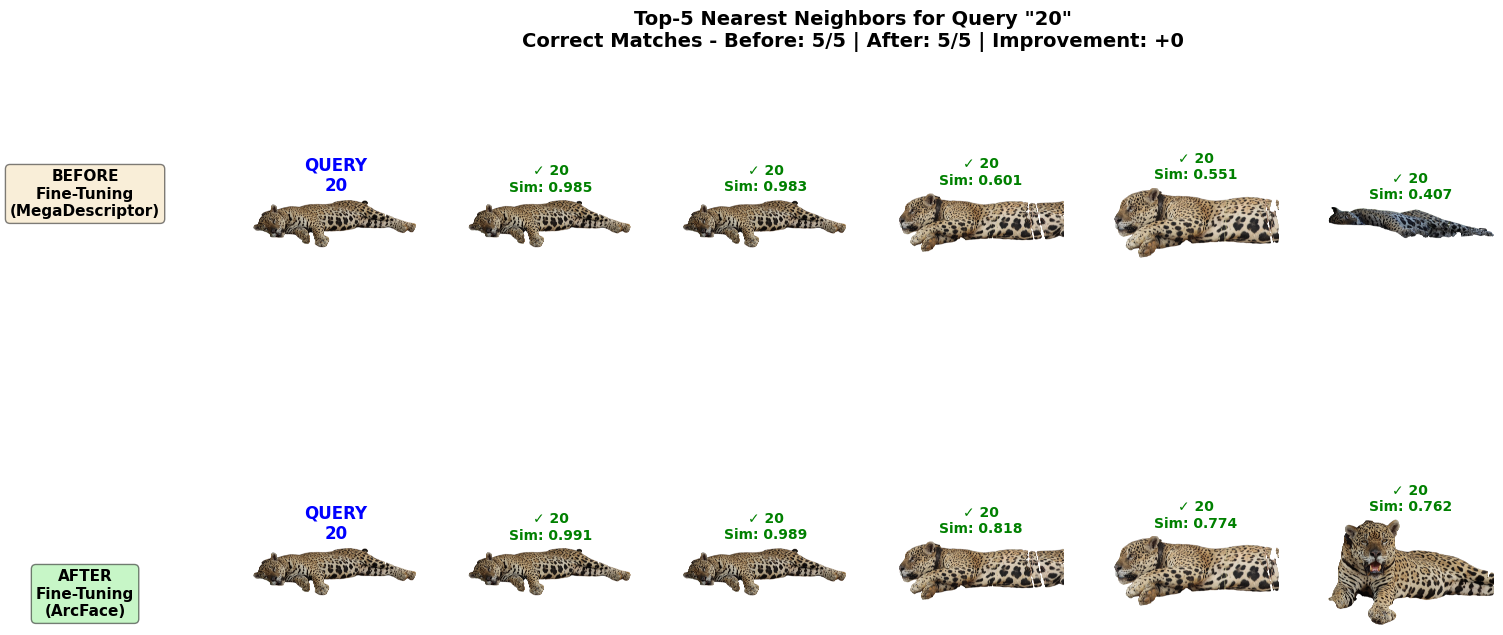

In [24]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=megadescriptor_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_megadescriptor.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_megadescriptor": wandb.Image(fig),
    "nearest_neighbors_stats_megadescriptor": stats,
})


In [25]:
del megadescriptor_dataset, megadescriptor_loader, megadescriptor_emb_train_dataset, megadescriptor_emb_val_dataset
del model, optimizer, scheduler, history
del megadescriptor_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## CLIP

**CLIP** is a vision–language model trained on large-scale image–text pairs. Although it was not specifically designed for wildlife re-identification, its large and diverse pretraining dataset enables it to learn strong and generalizable visual representations. This makes it a promising candidate for generating embeddings that may transfer well to the jaguar re-identification task.

In [26]:
# Load CLIP model
print("Loading CLIP model...")
clip = timm.create_model(
    config["clip_model"],
    pretrained=True
)
clip.eval()
clip.to(device)
clip.compile()

clip_config = resolve_data_config({}, model=clip)
clip_preprocess = create_transform(**clip_config, is_training=False)

clip_num_params = sum(p.numel() for p in clip.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {clip_num_params:,}")
print(f"  Preprocessing: {clip_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = clip_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = clip(dummy_input)
    clip_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {clip_dim}")
    
wandb.log({
    "clip_num_params": clip_num_params,
    "clip_embedding_dim": clip_dim,
    "clip_input_size": clip_config["input_size"],
    "clip_preprocessing": str(clip_config),
})

Loading CLIP model...
Model loaded successfully
  Parameters: 86,193,152
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.48145466, 0.4578275, 0.40821073], 'std': [0.26862954, 0.26130258, 0.27577711], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 512


In [27]:
clip_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=clip_preprocess
)
clip_loader = DataLoader(
    clip_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"CLIP DataLoader created with {len(clip_loader)} batches")

CLIP DataLoader created with 60 batches


In [28]:
clip_cache_path = OUTPUT_PATH / "clip_blur_embeddings.npz"

start_time = time.time()
clip_embeddings = get_embeddings(
    model=clip,
    cache_path=clip_cache_path,
    data_loader=clip_loader,
    filenames=filenames,
    device=device
)
clip_embedding_time = time.time() - start_time
print(f"Embeddings extracted in {clip_embedding_time:.2f} seconds")

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/02_backbone_comparison/clip_blur_embeddings.npz
Embeddings shape: (1895, 512)
Embeddings extracted in 0.06 seconds


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


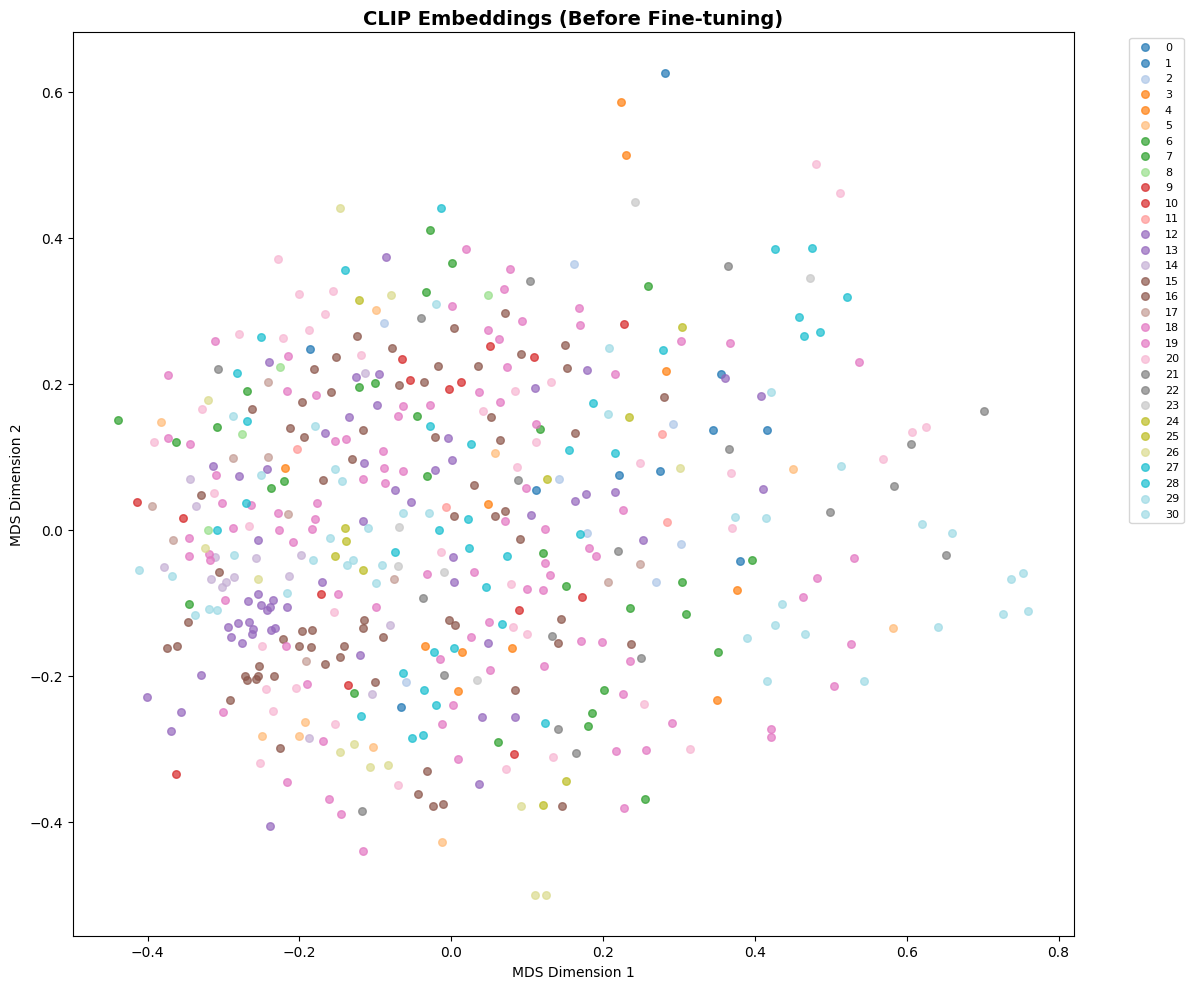

In [29]:
# Visualize CLIP embeddings
fig = visualize_embeddings_mds(
    clip_embeddings,
    labels,
    "CLIP Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "clip_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"clip_embeddings_mds": wandb.Image(fig)})

In [30]:
clip_emb_train_dataset = EmbeddingDataset(
    clip_embeddings[train_mask],
    train_labels
)

clip_emb_val_dataset = EmbeddingDataset(
    clip_embeddings[~train_mask],
    val_labels
)

clip_emb_train_loader = create_deterministic_training_dataloader(
    clip_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    seed=config["seed"]
)
clip_emb_val_loader = DataLoader(
    clip_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [31]:
# Create model
model = EmbeddingProjection(
    input_dim=clip_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 512
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 395520


In [32]:
# Setup training components
criterion.load_state_dict(torch.load(initial_criterion_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"]
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [33]:
# Training loop
set_seeds(config['seed'])
clip_checkpoint_path = CHECKPOINT_PATH / "best_clip_arcface.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    clip_emb_train_loader, 
    clip_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="clip",
    checkpoint_path=clip_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_clip": best_map,
    "best_epoch_clip": best_epoch,
    "total_epochs_clip": len(history['train_loss']),
    "training_time_clip": training_time
})

table.append([
    "CLIP",
    best_map,
    best_epoch,
    clip_num_params,
    sum(p.numel() for p in model.parameters()),
    clip_embedding_time,
    training_time
])

All random seeds set to 21 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 37.0018
  Val Loss:   34.1558
  Val mAP:    0.2411 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.7555
  Val Loss:   31.2792
  Val mAP:    0.2507 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 31.4129
  Val Loss:   29.0944
  Val mAP:    0.2635 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 29.6612
  Val Loss:   27.3492
  Val mAP:    0.2735 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.5421
  Val Loss:   6.8039
  Val mAP:    0.6872 | LR: 1.25e-05
  No improvement. Patience: 6/10

Epoch 127/200


  Train Loss: 0.5247
  Val Loss:   6.7429
  Val mAP:    0.6864 | LR: 1.25e-05
  No improvement. Patience: 7/10

Epoch 128/200


  Train Loss: 0.5565
  Val Loss:   6.7940
  Val mAP:    0.6886 | LR: 1.25e-05
  No improvement. Patience: 8/10

Epoch 129/200


  Train Loss: 0.5021
  Val Loss:   6.7924
  Val mAP:    0.6884 | LR: 1.25e-05
  No improvement. Patience: 9/10

Epoch 130/200


  Train Loss: 0.5392
  Val Loss:   6.7738
  Val mAP:    0.6849 | LR: 1.25e-05
  No improvement. Patience: 10/10

Early stopping triggered after 130 epochs

Training complete!
Best epoch: 120, Val mAP: 0.6904


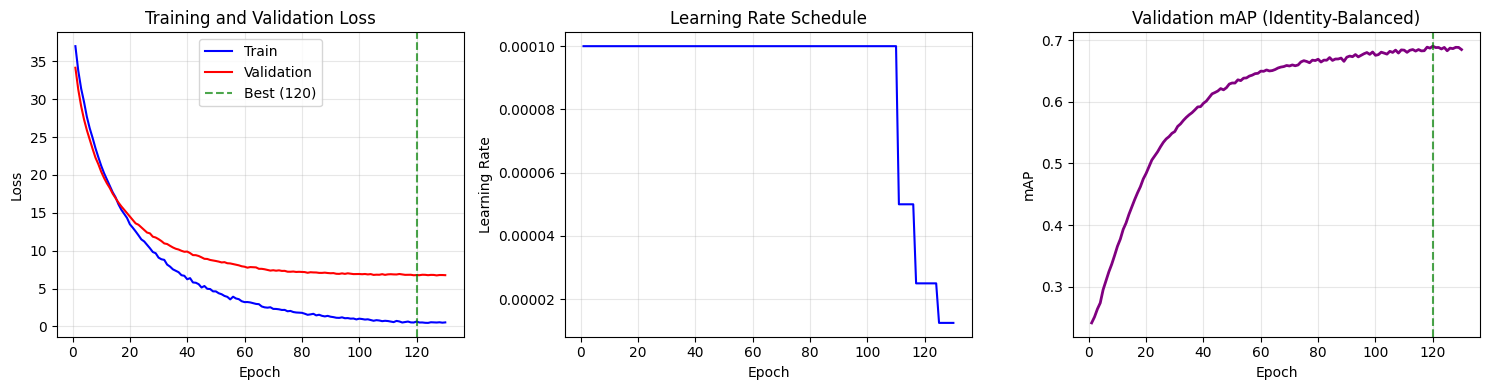

In [34]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_clip.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_clip": wandb.Image(fig)})

In [35]:
# Load best model
checkpoint = torch.load(clip_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 120
  Val mAP: 0.6904


In [36]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(clip_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


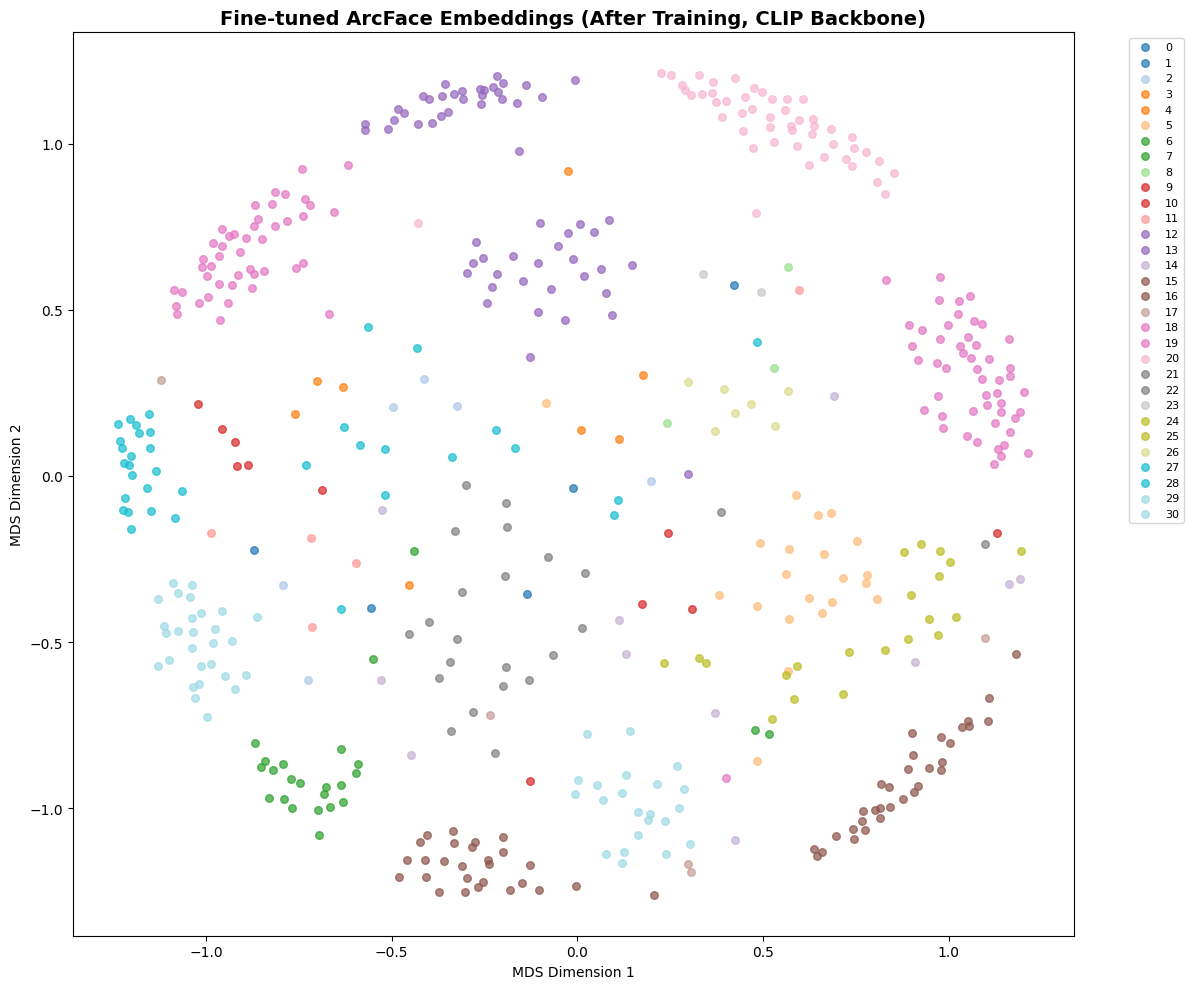

In [37]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, CLIP Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "clip_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_clip": wandb.Image(fig_finetuned)})

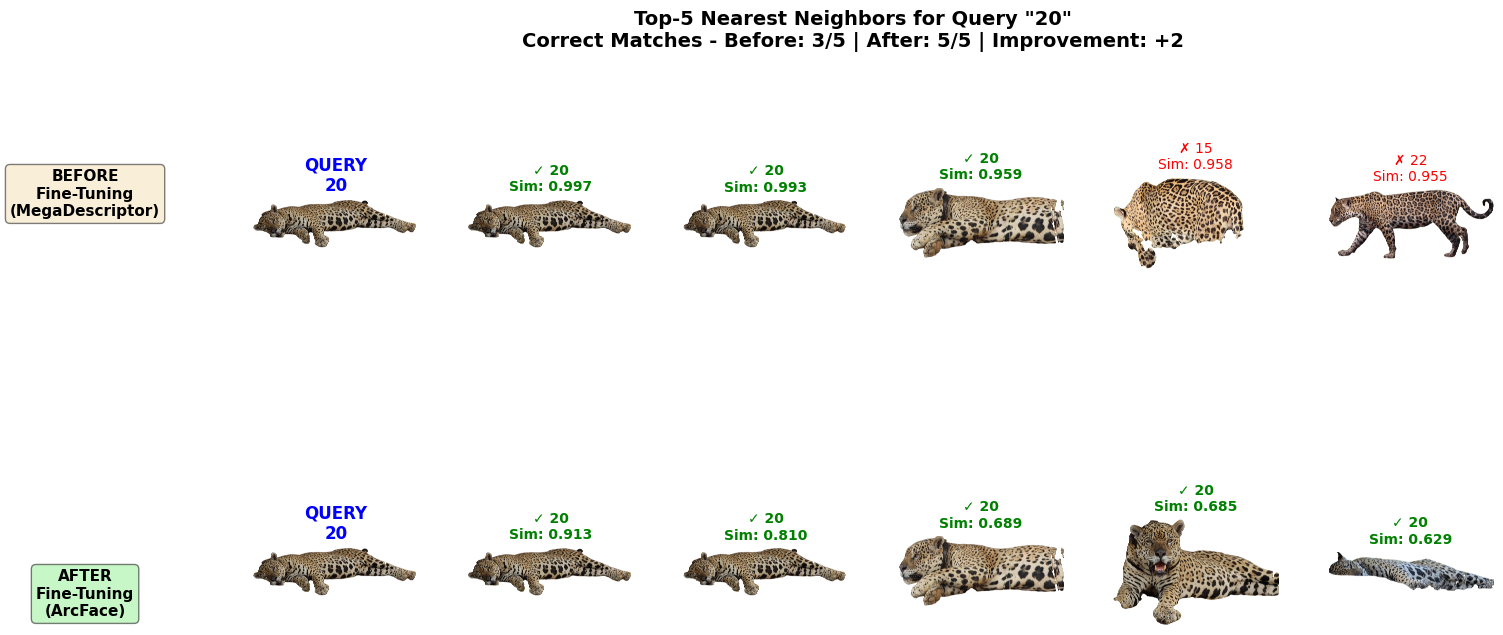

In [38]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=clip_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_clip.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_clip": wandb.Image(fig),
    "nearest_neighbors_stats_clip": stats,
})


In [39]:
del clip_dataset, clip_loader, clip_emb_train_dataset, clip_emb_val_dataset
del model, optimizer, scheduler, history
del clip_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## DINOv3

**DINOv3** is a self-supervised vision model that learns strong visual representations from unlabeled images. Its general-purpose embeddings make it a promising backbone for jaguar re-identification.


In [40]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [41]:
dino_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
dino_loader = DataLoader(
    dino_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"Dino DataLoader created with {len(dino_loader)} batches")

Dino DataLoader created with 60 batches


In [42]:
dino_cache_path = OUTPUT_PATH / "dino_blur_embeddings.npz"

start_time = time.time()
dino_embeddings = get_embeddings(
    model=dino,
    cache_path=dino_cache_path,
    data_loader=dino_loader,
    filenames=filenames,
    device=device
)
dino_embedding_time = time.time() - start_time
print(f"Embeddings extracted in {dino_embedding_time:.2f} seconds")

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/02_backbone_comparison/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)
Embeddings extracted in 0.08 seconds


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


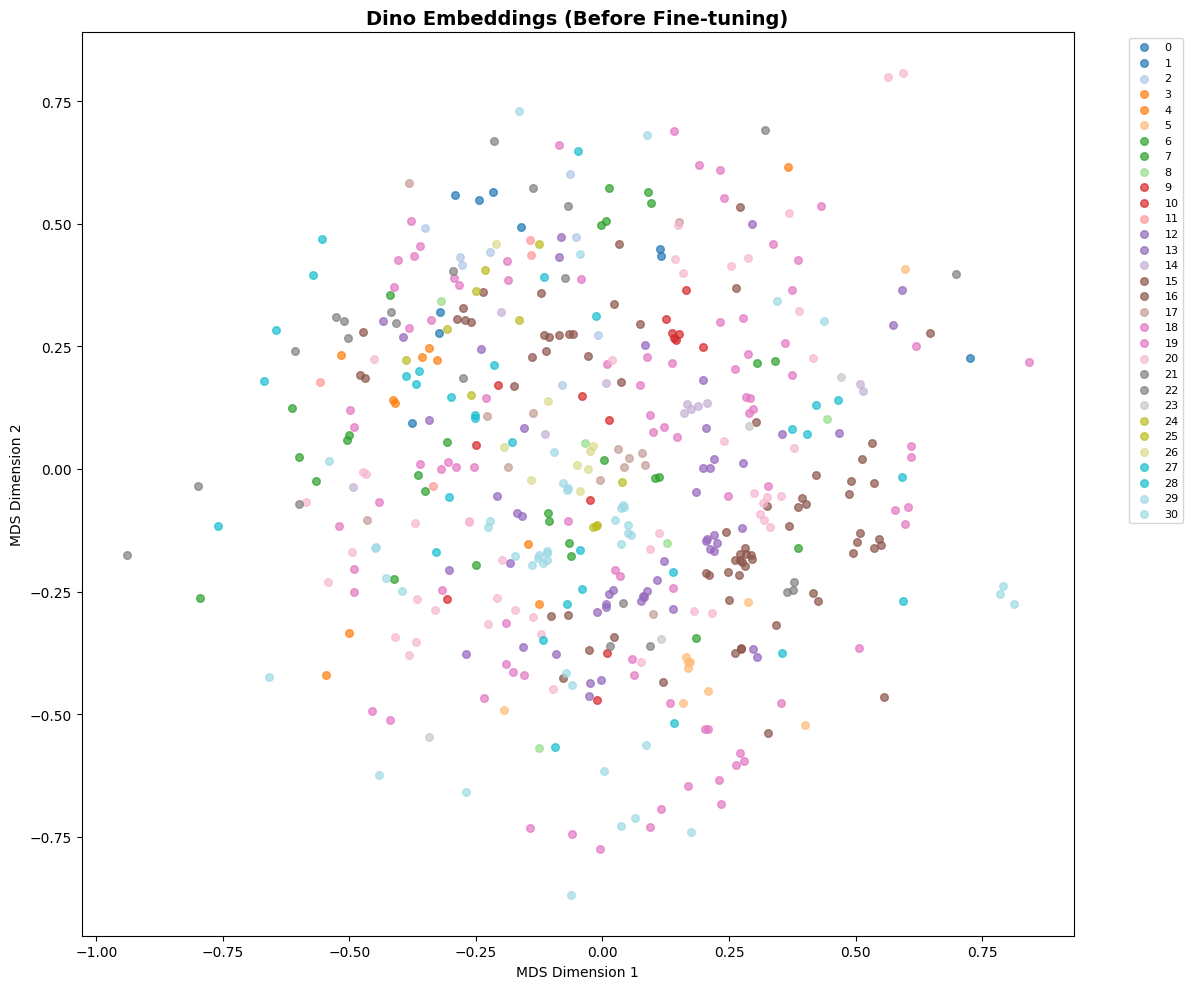

In [43]:
# Visualize Dino embeddings
fig = visualize_embeddings_mds(
    dino_embeddings,
    labels,
    "Dino Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "dino_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"dino_embeddings_mds": wandb.Image(fig)})

In [44]:
dino_emb_train_dataset = EmbeddingDataset(
    dino_embeddings[train_mask],
    train_labels
)

dino_emb_val_dataset = EmbeddingDataset(
    dino_embeddings[~train_mask],
    val_labels
)

dino_emb_train_loader = create_deterministic_training_dataloader(
    dino_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    seed=config["seed"]
)
dino_emb_val_loader = DataLoader(
    dino_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [45]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


In [46]:
# Setup training components
criterion.load_state_dict(torch.load(initial_criterion_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"]
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [47]:
# Training loop
set_seeds(config['seed'])
dino_checkpoint_path = CHECKPOINT_PATH / "best_dino_arcface.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    dino_emb_train_loader, 
    dino_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="dino",
    checkpoint_path=dino_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_dino": best_map,
    "best_epoch_dino": best_epoch,
    "total_epochs_dino": len(history['train_loss']),
    "training_time_dino": training_time
})

table.append([
    "Dino",
    best_map,
    best_epoch,
    dino_num_params,
    sum(p.numel() for p in model.parameters()),
    dino_embedding_time,
    training_time
])

All random seeds set to 21 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.5302
  Val Loss:   32.6073
  Val mAP:    0.3099 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.9563
  Val Loss:   28.2680
  Val mAP:    0.3232 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.7533
  Val Loss:   25.0208
  Val mAP:    0.3446 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.8291
  Val Loss:   21.9624
  Val mAP:    0.3673 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.2847
  Val Loss:   4.2647
  Val mAP:    0.7785 | LR: 3.13e-06
  No improvement. Patience: 6/10

Epoch 104/200


  Train Loss: 0.3264
  Val Loss:   4.2764
  Val mAP:    0.7786 | LR: 3.13e-06
  No improvement. Patience: 7/10

Epoch 105/200


  Train Loss: 0.2651
  Val Loss:   4.3015
  Val mAP:    0.7790 | LR: 3.13e-06
  No improvement. Patience: 8/10

Epoch 106/200


  Train Loss: 0.3141
  Val Loss:   4.2603
  Val mAP:    0.7774 | LR: 1.56e-06
  No improvement. Patience: 9/10

Epoch 107/200


  Train Loss: 0.3574
  Val Loss:   4.2351
  Val mAP:    0.7783 | LR: 1.56e-06
  No improvement. Patience: 10/10

Early stopping triggered after 107 epochs

Training complete!
Best epoch: 97, Val mAP: 0.7802


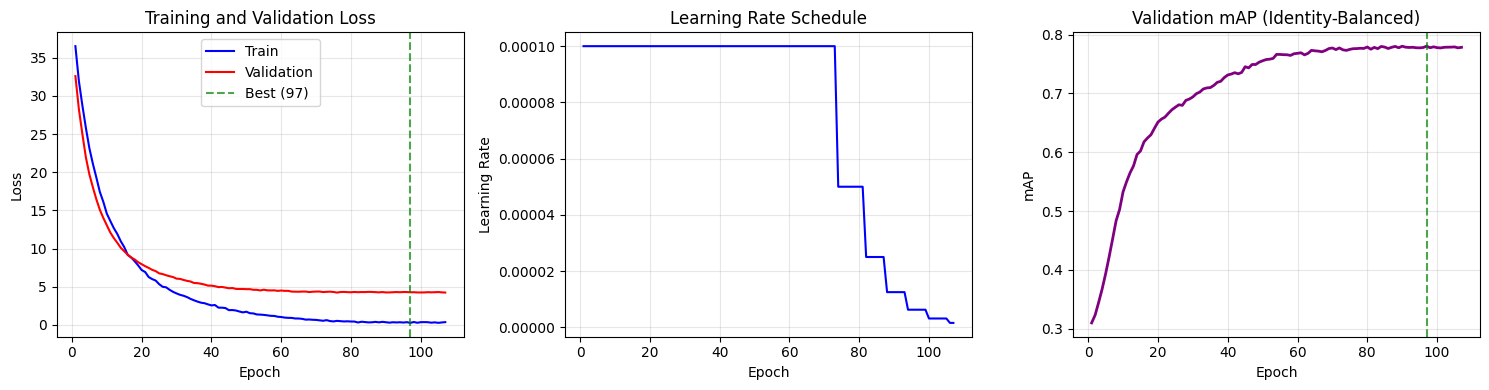

In [48]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_dino.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_dino": wandb.Image(fig)})

In [49]:
# Load best model
checkpoint = torch.load(dino_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 97
  Val mAP: 0.7802


In [50]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(dino_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


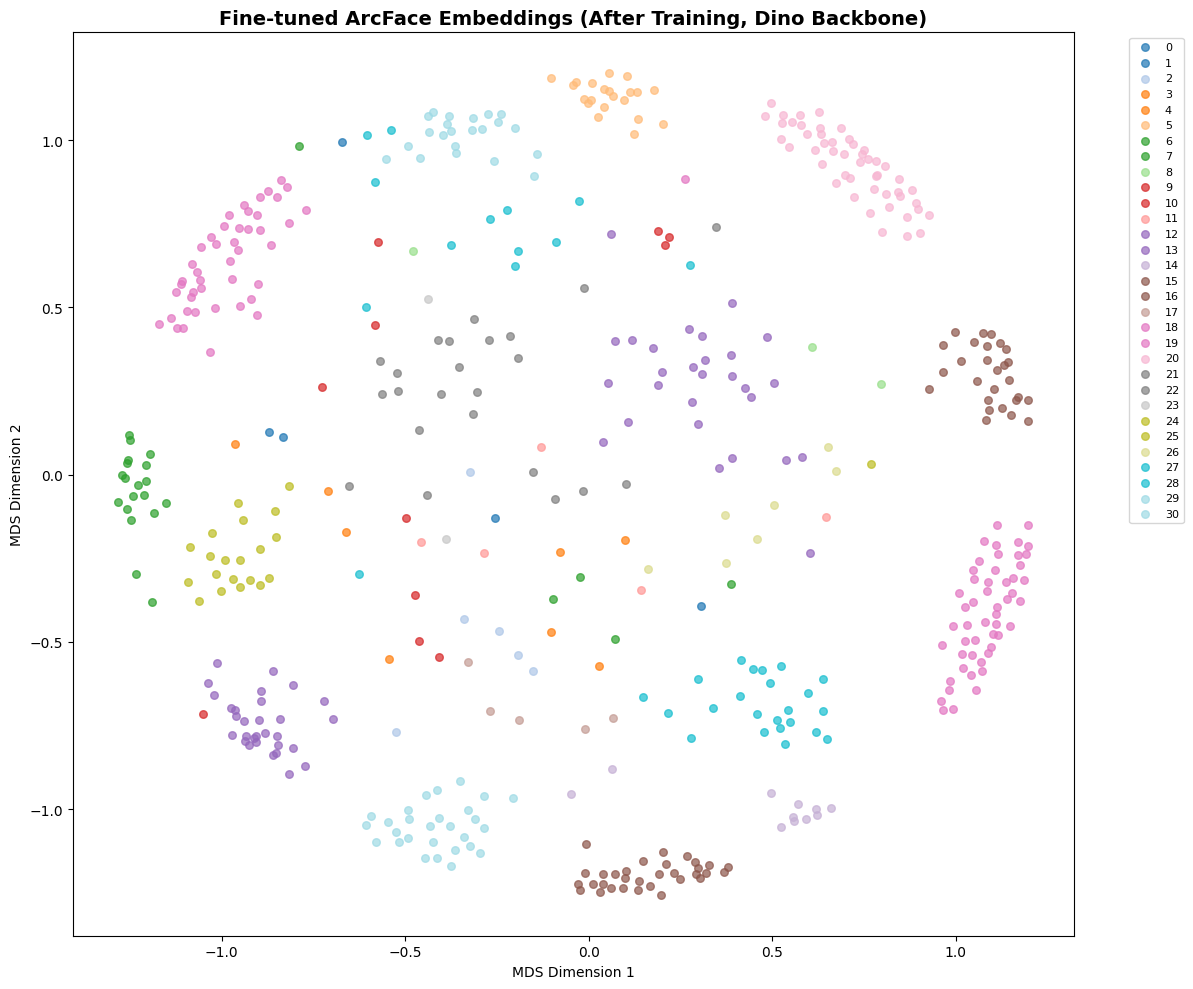

In [51]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, Dino Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "dino_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_dino": wandb.Image(fig_finetuned)})

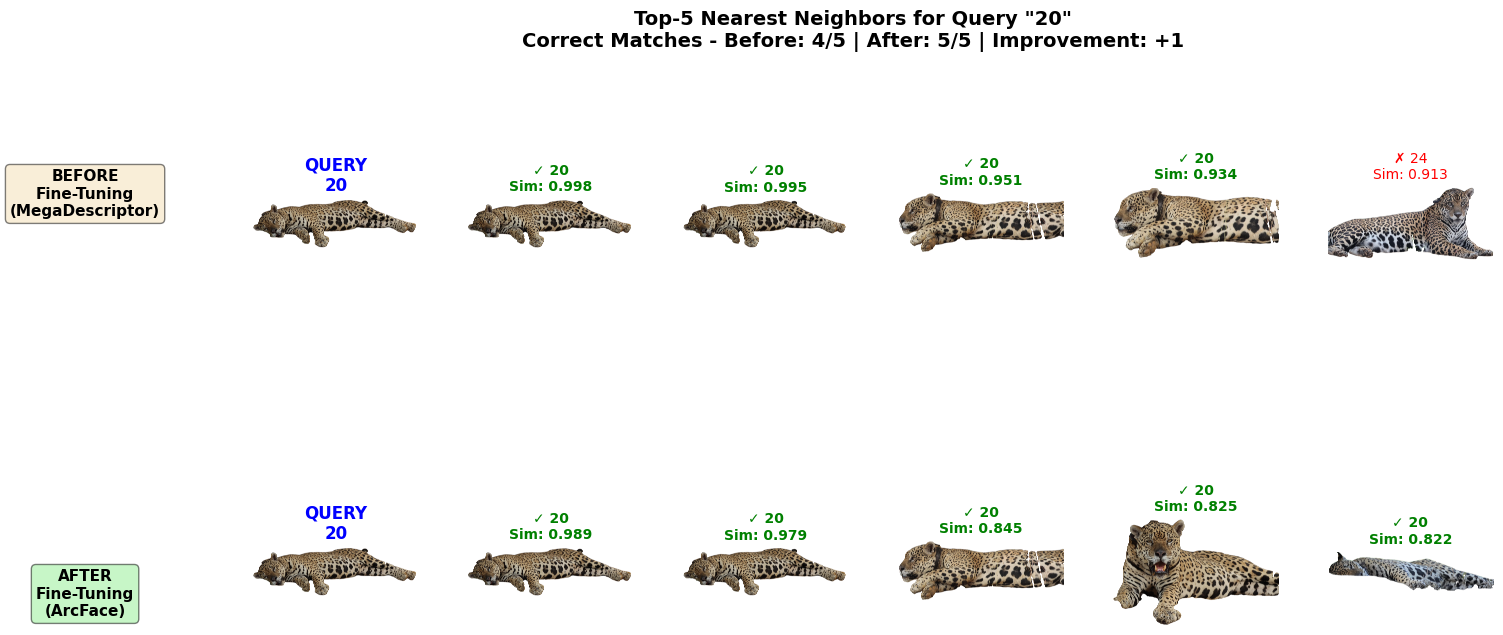

In [52]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=dino_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_dino.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_dino": wandb.Image(fig),
    "nearest_neighbors_stats_dino": stats,
})


In [53]:
del dino_dataset, dino_loader, dino_emb_train_dataset, dino_emb_val_dataset
del model, optimizer, scheduler, history
del dino_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## EfficientNet

**EfficientNet** is a convolutional neural network that balances accuracy and computational efficiency. Its pretrained embeddings are both compact and effective, making it a practical choice for jaguar re-identification.


In [54]:
# Load EfficientNet model
print("Loading EfficientNet model...")
efficientnet = timm.create_model(
    config["efficientnet_model"],
    pretrained=True
)
efficientnet.eval()
efficientnet.to(device)
efficientnet.compile()

efficientnet_config = resolve_data_config({}, model=efficientnet)
efficientnet_preprocess = create_transform(**efficientnet_config, is_training=False)

efficientnet_num_params = sum(p.numel() for p in efficientnet.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {efficientnet_num_params:,}")
print(f"  Preprocessing: {efficientnet_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = efficientnet_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = efficientnet(dummy_input)
    efficientnet_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {efficientnet_dim}")
    
wandb.log({
    "efficientnet_num_params": efficientnet_num_params,
    "efficientnet_embedding_dim": efficientnet_dim,
    "efficientnet_input_size": efficientnet_config["input_size"],
    "efficientnet_preprocessing": str(efficientnet_config),
})

Loading EfficientNet model...
Model loaded successfully
  Parameters: 5,288,548
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.875, 'crop_mode': 'center'}
  Embedding dimension: 1000


In [55]:
efficientnet_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=efficientnet_preprocess
)
efficientnet_loader = DataLoader(
    efficientnet_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"EfficientNet DataLoader created with {len(efficientnet_loader)} batches")

EfficientNet DataLoader created with 60 batches


In [56]:
efficientnet_cache_path = OUTPUT_PATH / "efficientnet_blur_embeddings.npz"

start_time = time.time()
efficientnet_embeddings = get_embeddings(
    model=efficientnet,
    cache_path=efficientnet_cache_path,
    data_loader=efficientnet_loader,
    filenames=filenames,
    device=device
)
efficientnet_embedding_time = time.time() - start_time
print(f"Embeddings extracted in {efficientnet_embedding_time:.2f} seconds")

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/02_backbone_comparison/efficientnet_blur_embeddings.npz
Embeddings shape: (1895, 1000)
Embeddings extracted in 0.07 seconds


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


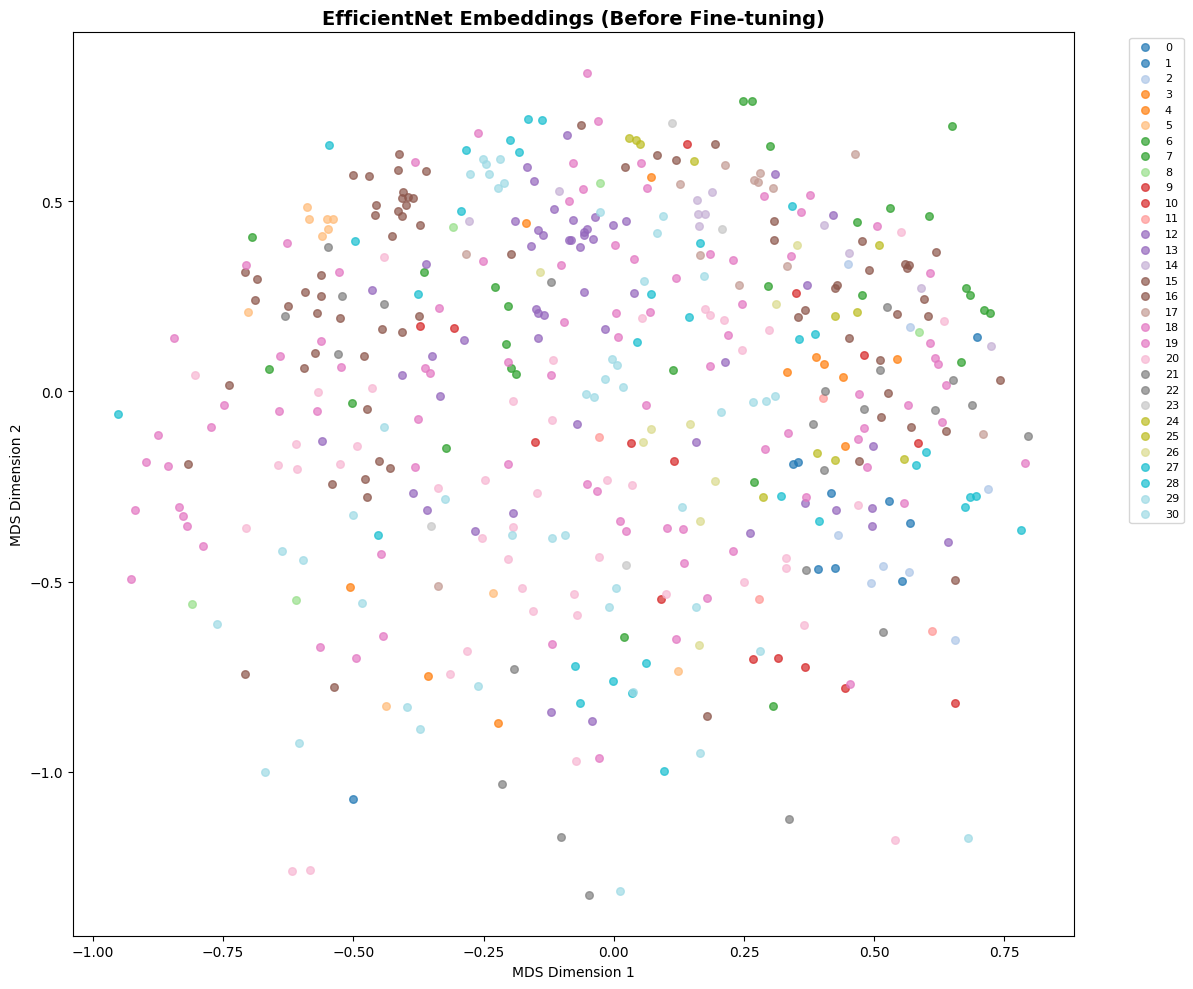

In [57]:
# Visualize EfficientNet embeddings
fig = visualize_embeddings_mds(
    efficientnet_embeddings,
    labels,
    "EfficientNet Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "efficientnet_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"efficientnet_embeddings_mds": wandb.Image(fig)})

In [58]:
efficientnet_emb_train_dataset = EmbeddingDataset(
    efficientnet_embeddings[train_mask],
    train_labels
)

efficientnet_emb_val_dataset = EmbeddingDataset(
    efficientnet_embeddings[~train_mask],
    val_labels
)

efficientnet_emb_train_loader = create_deterministic_training_dataloader(
    efficientnet_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    seed=config["seed"]
)
efficientnet_emb_val_loader = DataLoader(
    efficientnet_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [59]:
# Create model
model = EmbeddingProjection(
    input_dim=efficientnet_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 1000
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 645376


In [60]:
# Setup training components
criterion.load_state_dict(torch.load(initial_criterion_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"]
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [61]:
# Training loop
set_seeds(config['seed'])
efficientnet_checkpoint_path = CHECKPOINT_PATH / "best_efficientnet_arcface.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    efficientnet_emb_train_loader, 
    efficientnet_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="efficientnet",
    checkpoint_path=efficientnet_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_efficientnet": best_map,
    "best_epoch_efficientnet": best_epoch,
    "total_epochs_efficientnet": len(history['train_loss']),
    "training_time_efficientnet": training_time
})

table.append([
    "EfficientNet",
    best_map,
    best_epoch,
    efficientnet_num_params,
    sum(p.numel() for p in model.parameters()),
    efficientnet_embedding_time,
    training_time
])

All random seeds set to 21 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 37.0491
  Val Loss:   33.7028
  Val mAP:    0.2820 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.0323
  Val Loss:   29.9253
  Val mAP:    0.2964 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.9390
  Val Loss:   26.8816
  Val mAP:    0.3162 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.3455
  Val Loss:   5.8125
  Val mAP:    0.7174 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 101/200


  Train Loss: 0.3425
  Val Loss:   5.8242
  Val mAP:    0.7174 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 102/200


  Train Loss: 0.3288
  Val Loss:   5.6925
  Val mAP:    0.7197 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 103/200


  Train Loss: 0.3704
  Val Loss:   5.7169
  Val mAP:    0.7184 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 104/200


  Train Loss: 0.3053
  Val Loss:   5.6971
  Val mAP:    0.7183 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 104 epochs

Training complete!
Best epoch: 94, Val mAP: 0.7208


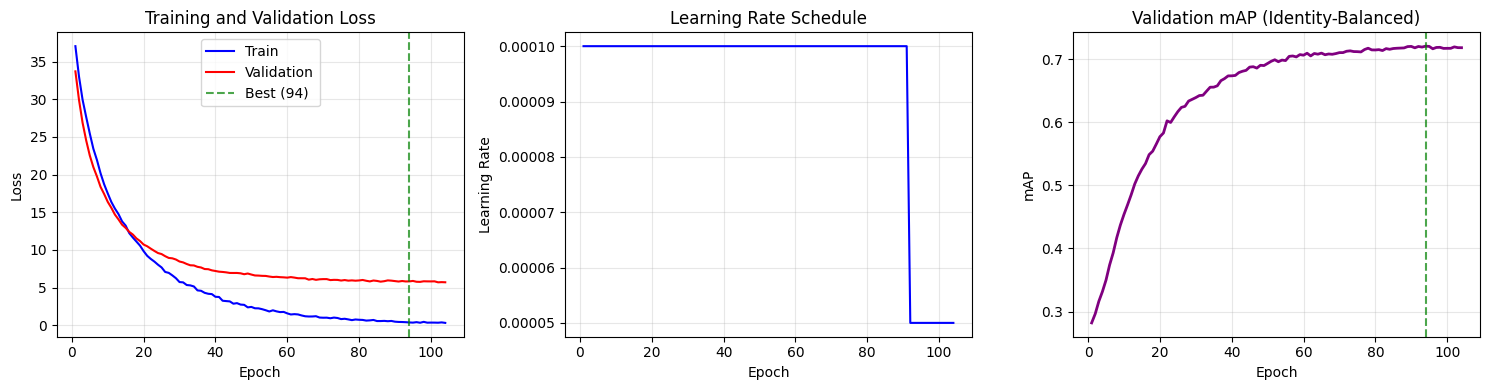

In [62]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_efficientnet": wandb.Image(fig)})

In [63]:
# Load best model
checkpoint = torch.load(efficientnet_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 94
  Val mAP: 0.7208


In [64]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(efficientnet_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


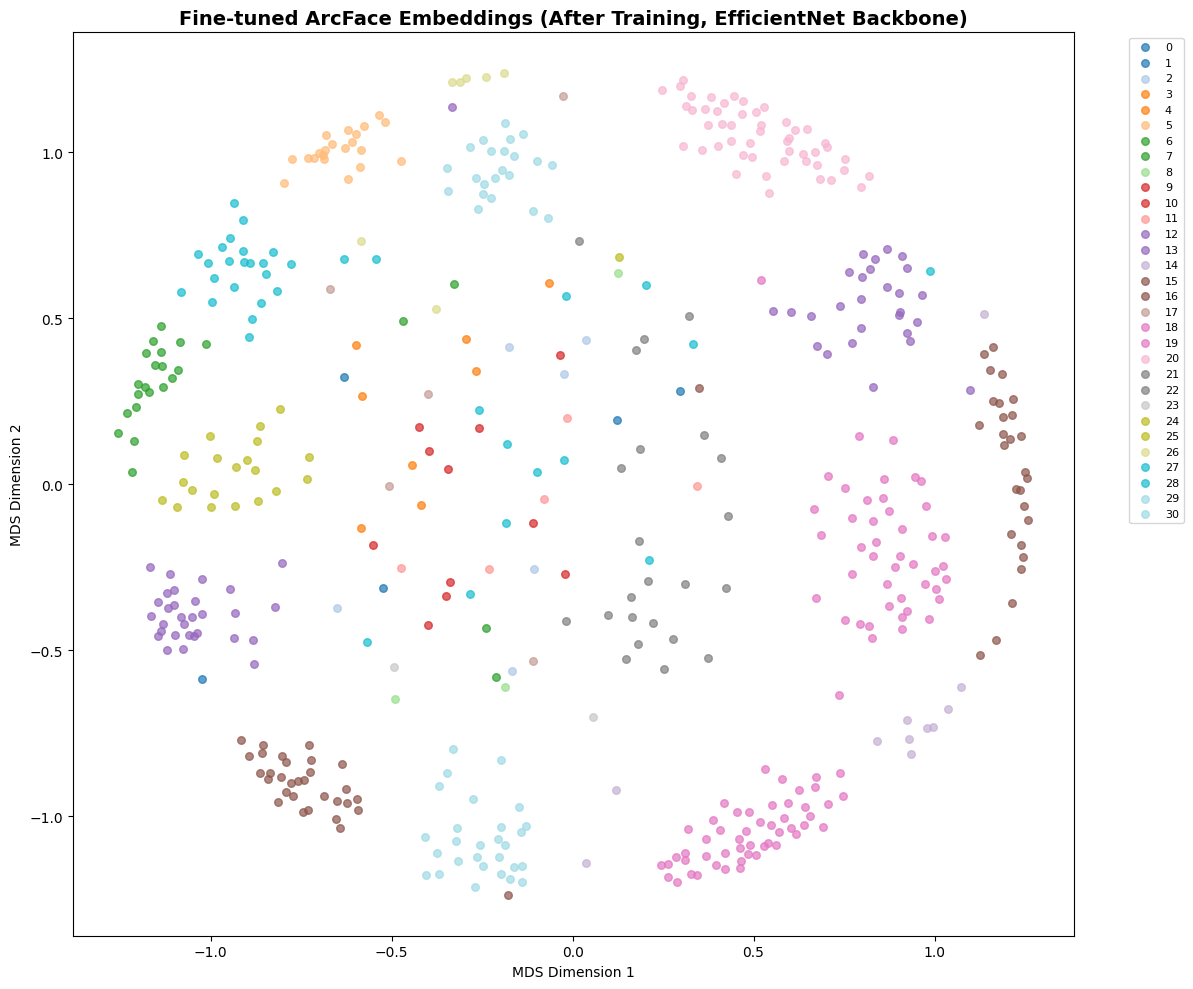

In [65]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, EfficientNet Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "efficientnet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_efficientnet": wandb.Image(fig_finetuned)})

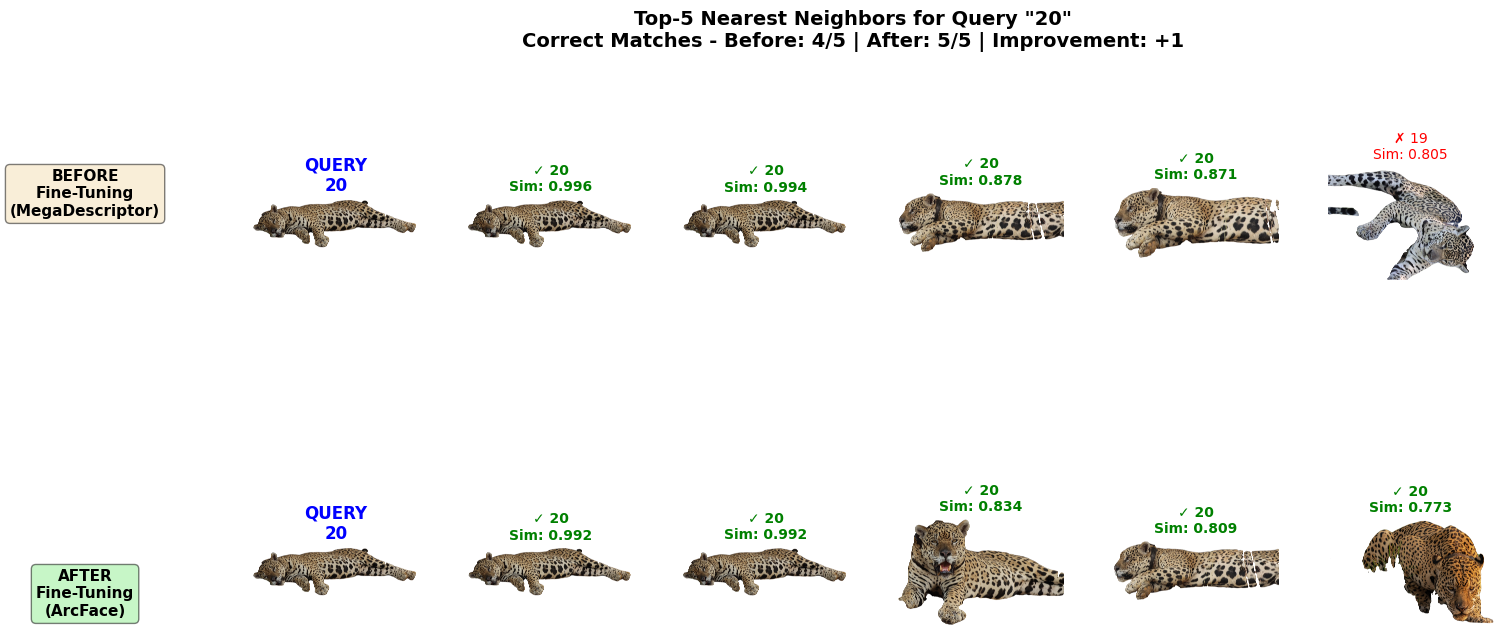

In [66]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=efficientnet_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_efficientnet.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_efficientnet": wandb.Image(fig),
    "nearest_neighbors_stats_efficientnet": stats,
})


In [67]:
del efficientnet_dataset, efficientnet_loader, efficientnet_emb_train_dataset, efficientnet_emb_val_dataset
del model, optimizer, scheduler, history
del efficientnet_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## ResNet18

**ResNet18** is a lightweight convolutional neural network known for its simplicity and efficiency. Its pretrained embeddings are fast to compute, making it a practical option for jaguar re-identification experiments.


In [68]:
# Load ResNet18 model
print("Loading ResNet18 model...")
resnet18 = timm.create_model(
    config["resnet18_model"],
    pretrained=True
)
resnet18.eval()
resnet18.to(device)
resnet18.compile()

resnet18_config = resolve_data_config({}, model=resnet18)
resnet18_preprocess = create_transform(**resnet18_config, is_training=False)

resnet18_num_params = sum(p.numel() for p in resnet18.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {resnet18_num_params:,}")
print(f"  Preprocessing: {resnet18_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = resnet18_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = resnet18(dummy_input)
    resnet18_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {resnet18_dim}")
    
wandb.log({
    "resnet18_num_params": resnet18_num_params,
    "resnet18_embedding_dim": resnet18_dim,
    "resnet18_input_size": resnet18_config["input_size"],
    "resnet18_preprocessing": str(resnet18_config),
})

Loading ResNet18 model...
Model loaded successfully
  Parameters: 11,689,512
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.95, 'crop_mode': 'center'}
  Embedding dimension: 1000


In [69]:
resnet18_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=resnet18_preprocess
)
resnet18_loader = DataLoader(
    resnet18_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"ResNet18 DataLoader created with {len(resnet18_loader)} batches")

ResNet18 DataLoader created with 60 batches


In [70]:
resnet18_cache_path = OUTPUT_PATH / "resnet18_blur_embeddings.npz"

start_time = time.time()
resnet18_embeddings = get_embeddings(
    model=resnet18,
    cache_path=resnet18_cache_path,
    data_loader=resnet18_loader,
    filenames=filenames,
    device=device
)
resnet18_embedding_time = time.time() - start_time
print(f"Embeddings extracted in {resnet18_embedding_time:.2f} seconds")

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/02_backbone_comparison/resnet18_blur_embeddings.npz
Embeddings shape: (1895, 1000)
Embeddings extracted in 0.06 seconds


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


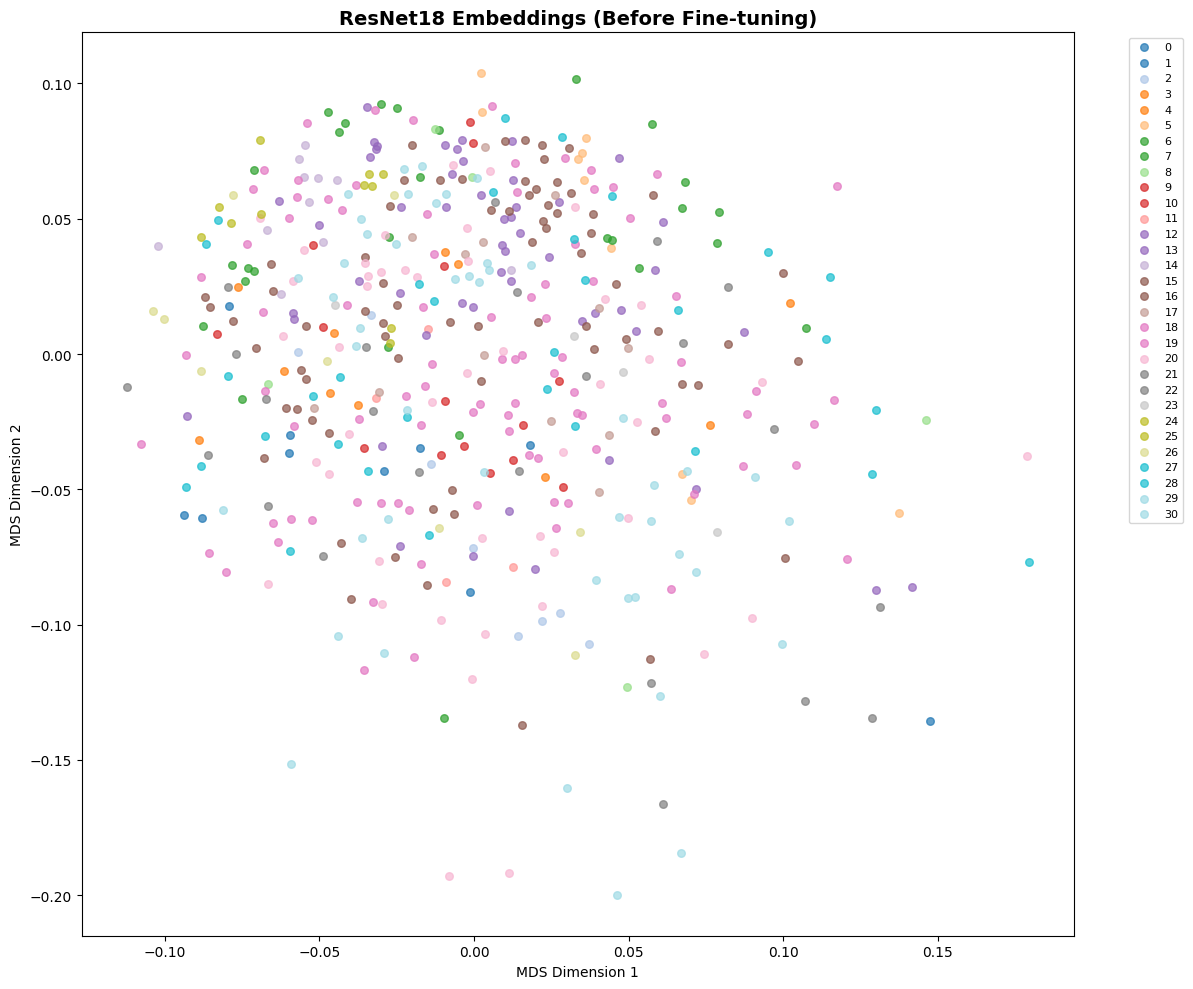

In [71]:
# Visualize ResNet18 embeddings
fig = visualize_embeddings_mds(
    resnet18_embeddings,
    labels,
    "ResNet18 Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "resnet18_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"resnet18_embeddings_mds": wandb.Image(fig)})

In [72]:
resnet18_emb_train_dataset = EmbeddingDataset(
    resnet18_embeddings[train_mask],
    train_labels
)

resnet18_emb_val_dataset = EmbeddingDataset(
    resnet18_embeddings[~train_mask],
    val_labels
)

resnet18_emb_train_loader = create_deterministic_training_dataloader(
    resnet18_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    seed=config["seed"]
)
resnet18_emb_val_loader = DataLoader(
    resnet18_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [73]:
model = EmbeddingProjection(
    input_dim=resnet18_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 1000
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 645376


In [74]:
# Setup training components
criterion.load_state_dict(torch.load(initial_criterion_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"]
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [75]:
# Training loop
set_seeds(config['seed'])
resnet18_checkpoint_path = CHECKPOINT_PATH / "best_resnet18_arcface.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    resnet18_emb_train_loader, 
    resnet18_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="resnet18",
    checkpoint_path=resnet18_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_resnet18": best_map,
    "best_epoch_resnet18": best_epoch,
    "total_epochs_resnet18": len(history['train_loss']),
    "training_time_resnet18": training_time
})

table.append([
    "ResNet18",
    best_map,
    best_epoch,
    resnet18_num_params,
    sum(p.numel() for p in model.parameters()),
    resnet18_embedding_time,
    training_time
])

All random seeds set to 21 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 37.3008
  Val Loss:   36.4630
  Val mAP:    0.2047 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.9529
  Val Loss:   33.8176
  Val mAP:    0.2150 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 31.9955
  Val Loss:   31.2445
  Val mAP:    0.2258 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 29.9569
  Val Loss:   30.4397
  Val mAP:    0.2422 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 5.0049
  Val Loss:   8.7450
  Val mAP:    0.5969 | LR: 6.25e-06
  No improvement. Patience: 6/10

Epoch 88/200


  Train Loss: 4.9839
  Val Loss:   8.7310
  Val mAP:    0.5946 | LR: 3.13e-06
  No improvement. Patience: 7/10

Epoch 89/200


  Train Loss: 5.1276
  Val Loss:   8.7332
  Val mAP:    0.5957 | LR: 3.13e-06
  No improvement. Patience: 8/10

Epoch 90/200


  Train Loss: 4.8582
  Val Loss:   8.5979
  Val mAP:    0.5985 | LR: 3.13e-06
  No improvement. Patience: 9/10

Epoch 91/200


  Train Loss: 4.8821
  Val Loss:   8.6568
  Val mAP:    0.5970 | LR: 3.13e-06
  No improvement. Patience: 10/10

Early stopping triggered after 91 epochs

Training complete!
Best epoch: 81, Val mAP: 0.5989


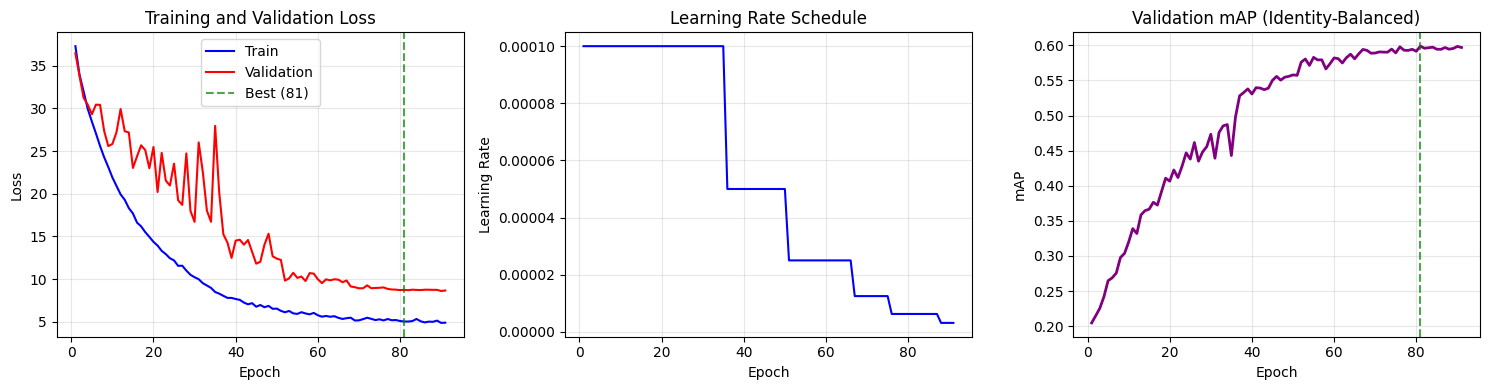

In [76]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_resnet18.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_resnet18": wandb.Image(fig)})

In [77]:
# Load best model
checkpoint = torch.load(resnet18_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 81
  Val mAP: 0.5989


In [78]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(resnet18_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


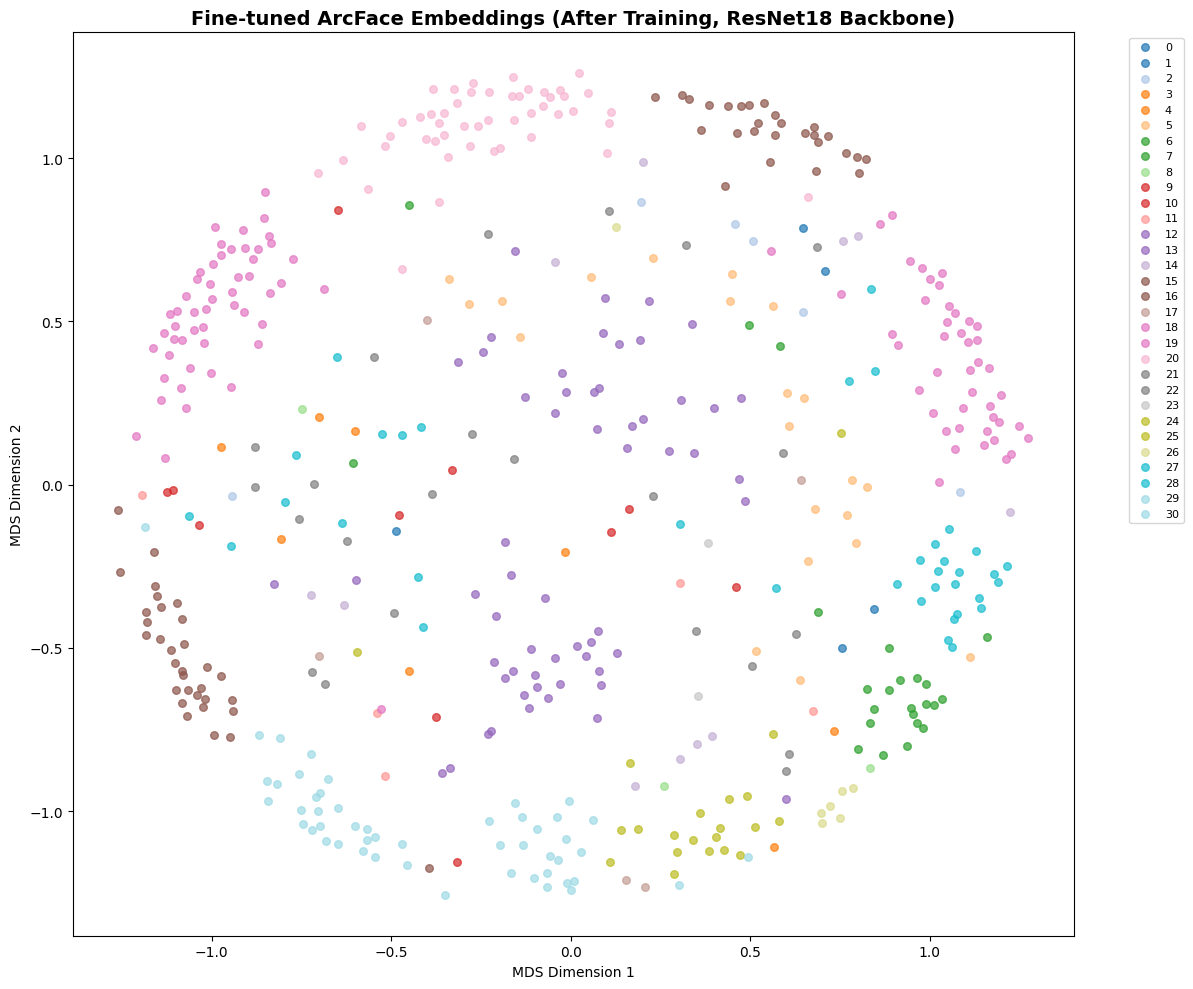

In [79]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, ResNet18 Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "resnet18_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_resnet18": wandb.Image(fig_finetuned)})

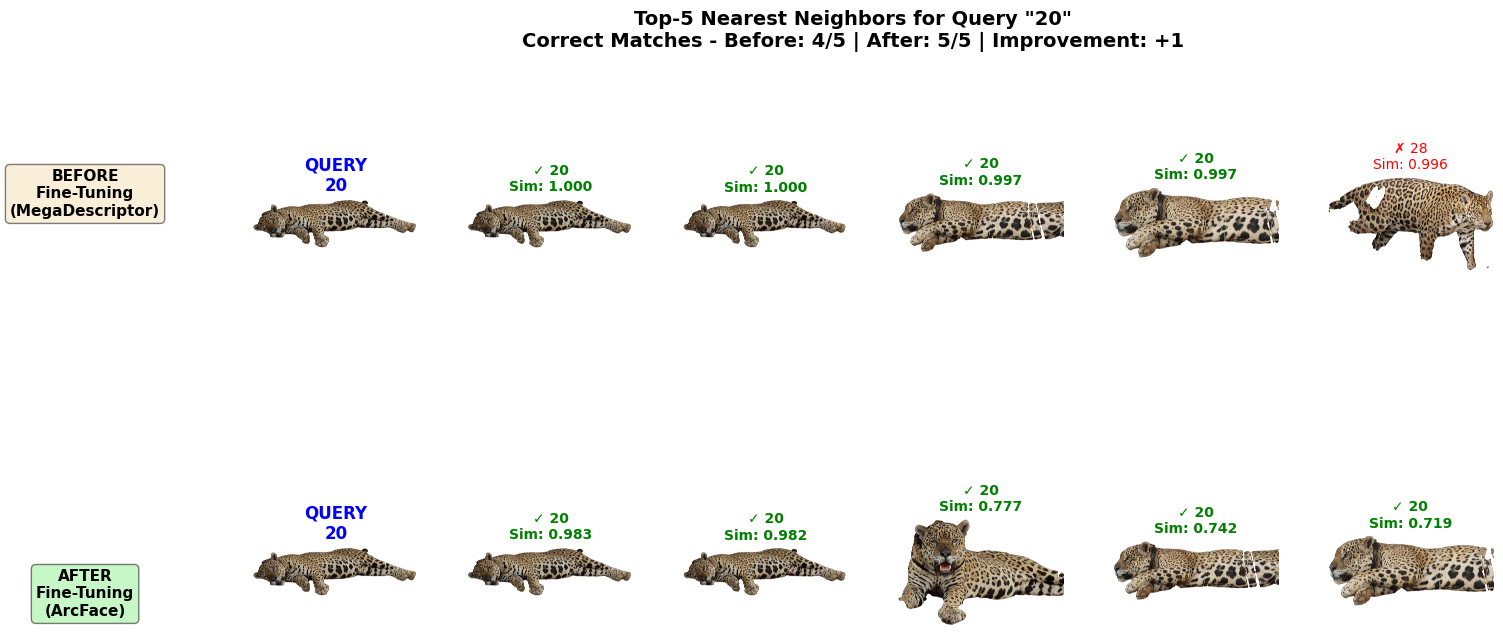

In [80]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=resnet18_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_resnet18.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_resnet18": wandb.Image(fig),
    "nearest_neighbors_stats_resnet18": stats,
})


In [81]:
del resnet18_dataset, resnet18_loader, resnet18_emb_train_dataset, resnet18_emb_val_dataset
del model, optimizer, scheduler, history
del resnet18_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## Summary

In [82]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-------------------+------------------+------------------+------------------+------------------+------------------+
| Backbone          |   MegaDescriptor |             CLIP |             Dino |     EfficientNet |         ResNet18 |
+===================+==================+==================+==================+==================+==================+
| Best val_mAP      |      0.733252    |      0.690422    |      0.780221    |      0.720779    |      0.598869    |
+-------------------+------------------+------------------+------------------+------------------+------------------+
| Best epoch        |     56           |    120           |     97           |     94           |     81           |
+-------------------+------------------+------------------+------------------+------------------+------------------+
| Backbone Params   |      1.95199e+08 |      8.61932e+07 |      8.56412e+07 |      5.28855e+06 |      1.16895e+07 |
+-------------------+------------------+------------------+-----

In [83]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

         Backbone  Best val_mAP  Best epoch  Backbone Params  \
0  MegaDescriptor      0.733252          56        195198516   
1            CLIP      0.690422         120         86193152   
2            Dino      0.780221          97         85641216   
3    EfficientNet      0.720779          94          5288548   
4        ResNet18      0.598869          81         11689512   

   Projection Params  Embedding Time  Training Time  
0             919808        0.061759     110.864121  
1             395520        0.055327     219.017654  
2             526592        0.083973     204.753969  
3             645376        0.074665     205.574739  
4             645376        0.064312     172.194472  


Result with random seed 4:
| Backbone           | MegaDescriptor | CLIP     | Dino     | EfficientNet | ResNet18 |
|--------------------|---------------|----------|----------|--------------|----------|
| Best val_mAP       | 0.845019      | 0.802713 | **0.870783** | 0.830311     | 0.650435 |
| Best epoch         | 106           | 148      | **77**       | 81           | 102      |
| Backbone Params    | 1.95199e+08   | 8.61932e+07 | 8.56412e+07 | 5.28855e+06 | 1.16895e+07 |
| Projection Params  | 919808        | 395520   | 526592   | 645376       | 645376   |
| Embedding Time     | 337.8         | **295.694**  | 303.796  | 303.788      | 320.993  |
| Training Time      | **177.643**       | 350.509  | 199.919  | 204.349      | 249.252  |

Result with random seed 7:
| Backbone           | MegaDescriptor | CLIP      | Dino      | EfficientNet | ResNet18 |
|--------------------|---------------|-----------|-----------|--------------|----------|
| Best val_mAP       | 0.814579      | 0.794566  | **0.845053**  | 0.762886     | 0.664405 |
| Best epoch         | **67**            | 116       | 69        | 116          | 71       |
| Backbone Params    | 1.95199e+08   | 8.61932e+07 | 8.56412e+07 | 5.28855e+06 | 1.16895e+07 |
| Projection Params  | 919808        | 395520    | 526592    | 645376       | 645376   |
| Embedding Time     | 0.105402      | 0.0751777 | 0.0758331 | 0.0742304    | 0.102103 |
| Training Time      | **169.266 **      | 274.017   | 173.097   | 274.23       | 175.434  |

Result with random seed 90:
| Backbone           | MegaDescriptor | CLIP      | Dino      | EfficientNet | ResNet18 |
|--------------------|---------------|-----------|-----------|--------------|----------|
| Best val_mAP       | 0.784838      | 0.776417  | **0.829684**  | 0.773556     | 0.663641 |
| Best epoch         | 90            | 154       | **89**        | 102          | 93       |
| Backbone Params    | 1.95199e+08   | 8.61932e+07 | 8.56412e+07 | 5.28855e+06 | 1.16895e+07 |
| Projection Params  | 919808        | 395520    | 526592    | 645376       | 645376   |
| Embedding Time     | 0.0722642     | 0.0362644 | 0.0590441 | 0.0623055    | 0.068485 |
| Training Time      | 201.52        | 327.447   | **199.245**   | 227.231      | 201.244  |

Result with random seed 856:
| Backbone           | MegaDescriptor | CLIP      | Dino      | EfficientNet | ResNet18 |
|--------------------|---------------|-----------|-----------|--------------|----------|
| Best val_mAP       | 0.765074      | 0.735205  | **0.812577**  | 0.780844     | 0.626006 |
| Best epoch         | 83            | 115       | 84        | **72**           | 104      |
| Backbone Params    | 1.95199e+08   | 8.61932e+07 | 8.56412e+07 | 5.28855e+06 | 1.16895e+07 |
| Projection Params  | 919808        | 395520    | 526592    | 645376       | 645376   |
| Embedding Time     | 0.0809741     | 0.0437493 | 0.0567925 | 0.0633271    | 0.0759923 |
| Training Time      | 193.843       | 259.81    | 196.556   | **171.965**      | 238.499  |

Result with random seed 21:
| Backbone           | MegaDescriptor | CLIP      | Dino      | EfficientNet | ResNet18 |
|--------------------|---------------|-----------|-----------|--------------|----------|
| Best val_mAP       | 0.733252      | 0.690422  | **0.780221**  | 0.720779     | 0.598869 |
| Best epoch         | **56**            | 120       | 97        | 94           | 81       |
| Backbone Params    | 1.95199e+08   | 8.61932e+07 | 8.56412e+07 | 5.28855e+06 | 1.16895e+07 |
| Projection Params  | 919808        | 395520    | 526592    | 645376       | 645376   |
| Embedding Time     | 0.0617595     | 0.0553272 | 0.0839729 | 0.0746648    | 0.0643122 |
| Training Time      | **110.864**       | 219.018   | 204.754   | 205.575      | 172.194  |

| Backbone       | Seed 4       | Seed 7       | Seed 90      | Seed 856     | Seed 21      | Mean mAP     | Std (mAP) | Mean Epoch | Mean Embedding Time | Mean Training Time | Avg Position |
| -------------- | ------------ | ------------ | ------------ | ------------ | ------------ | ------------ | --------- | ---------- | ------------------- | ------------------ | ------------ |
| MegaDescriptor | 0.845019     | 0.814579     | 0.784838     | 0.765074     | 0.733252     | 0.788552     | 0.043269  | 90.0       | 135.0               | 172.467            | 2.2          |
| CLIP           | 0.802713     | 0.794566     | 0.776417     | 0.735205     | 0.690422     | 0.759465     | 0.046756  | 130.6      | 90.8                | 234.356            | 3.6          |
| Dino           | **0.870783** | **0.845053** | **0.829684** | **0.812577** | **0.780221** | **0.827664** | 0.034074  | 83.4       | 104.7               | 174.314            | **1.0**      |
| EfficientNet   | 0.830311     | 0.762886     | 0.773556     | 0.780844     | 0.720779     | 0.773675     | 0.039286  | 90.6       | 141.1               | 196.480            | 3.4          |
| ResNet18       | 0.650435     | 0.664405     | 0.663641     | 0.626006     | 0.598869     | 0.640671     | 0.028057  | 90.2       | 136.4               | 187.938            | 5.0          |

Across the five seeds, the **DINOv3 backbone** consistently achieves the highest validation performance, with a mean mAP of **0.828** and the best average rank. MegaDescriptor is the next strongest performer with moderate difference.

For optimal re-identification performance, **DINOv3** should be used as the backbone in future notebooks.


## Submission

In [84]:
submission_model = "dinov3"

submission_dict = {
    "megadescriptor": (megadescriptor, megadescriptor_preprocess, megadescriptor_dim, megadescriptor_checkpoint_path),
    "clip": (clip, clip_preprocess, clip_dim, clip_checkpoint_path),
    "dinov3": (dino, dino_preprocess, dino_dim, dino_checkpoint_path),
    "efficient_net": (efficientnet, efficientnet_preprocess, efficientnet_dim, efficientnet_checkpoint_path),
    "resnet18": (resnet18, resnet18_preprocess, resnet18_dim, resnet18_checkpoint_path),
}

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

embedding_model, preprocess_fn, dim, checkpoint_path = submission_dict[submission_model]

wandb.log({"submission_type": submission_model})

In [85]:
# Create model
model = EmbeddingProjection(
    input_dim=dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [86]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [87]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=preprocess_fn
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=embedding_model,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [00:57<00:00,  4.77s/it]

Test embeddings shape: (371, 768)


In [88]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [89]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 32884.52it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9958
  Mean: 0.0669
  Std: 0.1401


In [90]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.414834
1       1    0.000000
2       2    0.270897
3       3    0.176070
4       4    0.138597
5       5    0.152642
6       6    0.116227
7       7    0.076622
8       8    0.168340
9       9    0.010123

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [91]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/02_backbone_comparison/submission.csv
File size: 1794.7 KB


## Artifacts

In [92]:
# Save model as W&B artifact
for key in submission_dict:
    _, _, _, checkpoint_path = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"arcface-model-{key}",
        type="model",
        description="ArcFace fine-tuned MegaDescriptor model for jaguar re-identification with backbone: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [93]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} backbone"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [94]:
wandb.finish()

best_epoch_clip,▁
best_epoch_dino,▁
best_epoch_efficientnet,▁
best_epoch_megadescriptor,▁
best_epoch_resnet18,▁
clip_embedding_dim,▁
clip_num_params,▁
dino_embedding_dim,▁
dino_num_params,▁
efficientnet_embedding_dim,▁
+28,...


Public submission score for seed 90 and DINOv3: 0.751